<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Algopro/AlgoPro%20LSTM%20demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title BoW
from collections import Counter

sent_a = "everything about this movie was bad nothing was good"
sent_b = "nothing about this movie was bad everything was good"

bow_a = Counter(sent_a.lower().split())
bow_b = Counter(sent_b.lower().split())

print("Sentence A:", sent_a)
print("Sentence B:", sent_b)
print()
print("BoW A:", dict(bow_a))
print("BoW B:", dict(bow_b))
print("Identical?", bow_a == bow_b)

Sentence A: everything about this movie was bad nothing was good
Sentence B: nothing about this movie was bad everything was good

BoW A: {'everything': 1, 'about': 1, 'this': 1, 'movie': 1, 'was': 2, 'bad': 1, 'nothing': 1, 'good': 1}
BoW B: {'nothing': 1, 'about': 1, 'this': 1, 'movie': 1, 'was': 2, 'bad': 1, 'everything': 1, 'good': 1}
Identical? True


In [ ]:
# @title Embeddings
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

embedding_table = {
    "everything": torch.tensor([ 0.5,  0.0,  1.0,  0.2]),
    "nothing":    torch.tensor([-0.5,  0.0,  1.0,  0.2]),
    "about":      torch.tensor([ 0.0,  0.0,  0.0,  1.0]),
    "this":       torch.tensor([ 0.0,  0.0,  0.0,  1.0]),
    "movie":      torch.tensor([ 0.0,  1.0,  0.0,  0.0]),
    "was":        torch.tensor([ 0.0,  0.0,  0.0,  1.0]),
    "bad":        torch.tensor([-1.0,  0.0,  0.8,  0.0]),
    "good":       torch.tensor([ 1.0,  0.0,  0.8,  0.0]),
}

def sentence_to_embeddings(sentence):
    tokens = sentence.lower().split()
    return tokens, torch.stack([embedding_table[t] for t in tokens])

tokens_a, embs_a = sentence_to_embeddings(sent_a)
tokens_b, embs_b = sentence_to_embeddings(sent_b)

print("Embedding sum A:", embs_a.sum(dim=0))
print("Embedding sum B:", embs_b.sum(dim=0))
print("Identical sums?", torch.allclose(embs_a.sum(dim=0), embs_b.sum(dim=0)))

Embedding sum A: tensor([0.0000, 1.0000, 3.6000, 4.4000])
Embedding sum B: tensor([0.0000, 1.0000, 3.6000, 4.4000])
Identical sums? True


In [ ]:
# @title RNN
EMBED_DIM = 4
HIDDEN_DIM = 8

class SimpleRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.3)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.3)
        self.b = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x_t, h_prev):
        h_t = torch.tanh(x_t @ self.W_xh + h_prev @ self.W_hh + self.b)
        return h_t

def run_rnn(cell, embeddings):
    h = torch.zeros(HIDDEN_DIM)
    states = []
    for t in range(embeddings.shape[0]):
        h = cell(embeddings[t], h)
        states.append(h)
    return states

In [ ]:
torch.manual_seed(42)
rnn_cell = SimpleRNNCell(EMBED_DIM, HIDDEN_DIM)
rnn_classifier = nn.Linear(HIDDEN_DIM, 1)

# snapshot before training
with torch.no_grad():
    states_a_before = torch.stack(run_rnn(rnn_cell, embs_a))
    states_b_before = torch.stack(run_rnn(rnn_cell, embs_b))

# train
optimizer = optim.Adam(list(rnn_cell.parameters()) + list(rnn_classifier.parameters()), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(501):
    optimizer.zero_grad()
    h_a = run_rnn(rnn_cell, embs_a)[-1]
    h_b = run_rnn(rnn_cell, embs_b)[-1]
    logit_a = rnn_classifier(h_a)
    logit_b = rnn_classifier(h_b)
    loss = loss_fn(logit_a, torch.tensor([0.0])) + loss_fn(logit_b, torch.tensor([1.0]))
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        with torch.no_grad():
            pa = torch.sigmoid(logit_a).item()
            pb = torch.sigmoid(logit_b).item()
        print(f"Epoch {epoch:3d}: loss={loss.item():.4f}  P(positive | A)={pa:.4f}  P(positive | B)={pb:.4f}")

Epoch   0: loss=1.4067  P(positive | A)=0.5782  P(positive | B)=0.5807
Epoch 100: loss=0.0097  P(positive | A)=0.0045  P(positive | B)=0.9949
Epoch 200: loss=0.0035  P(positive | A)=0.0017  P(positive | B)=0.9982
Epoch 300: loss=0.0020  P(positive | A)=0.0009  P(positive | B)=0.9990
Epoch 400: loss=0.0013  P(positive | A)=0.0006  P(positive | B)=0.9994
Epoch 500: loss=0.0009  P(positive | A)=0.0004  P(positive | B)=0.9995


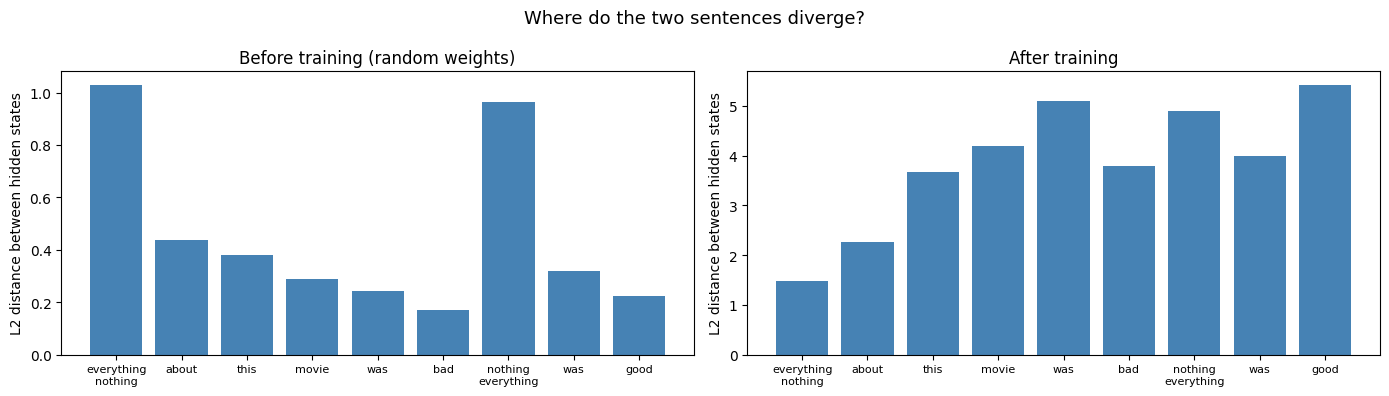

In [ ]:
with torch.no_grad():
    states_a_after = torch.stack(run_rnn(rnn_cell, embs_a))
    states_b_after = torch.stack(run_rnn(rnn_cell, embs_b))

diffs_before = torch.norm(states_a_before - states_b_before, dim=1)
diffs_after = torch.norm(states_a_after - states_b_after, dim=1)

combined_labels = [
    f"{a}\n{b}" if a != b else a
    for a, b in zip(tokens_a, tokens_b)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(diffs_before)), diffs_before.numpy(), color="steelblue")
axes[0].set_title("Before training (random weights)")
axes[0].set_ylabel("L2 distance between hidden states")
axes[0].set_xticks(range(len(combined_labels)))
axes[0].set_xticklabels(combined_labels, fontsize=8)

axes[1].bar(range(len(diffs_after)), diffs_after.numpy(), color="steelblue")
axes[1].set_title("After training")
axes[1].set_ylabel("L2 distance between hidden states")
axes[1].set_xticks(range(len(combined_labels)))
axes[1].set_xticklabels(combined_labels, fontsize=8)

plt.suptitle("Where do the two sentences diverge?", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# @title Long sequences
extra_words = {
    "despite":    torch.tensor([ 0.0,  0.0,  0.0,  0.8]),
    "the":        torch.tensor([ 0.0,  0.0,  0.0,  1.0]),
    "amazing":    torch.tensor([ 0.9,  0.0,  0.9,  0.0]),
    "cast":       torch.tensor([ 0.0,  0.8,  0.0,  0.0]),
    "brilliant":  torch.tensor([ 0.9,  0.0,  0.9,  0.0]),
    "director":   torch.tensor([ 0.0,  0.8,  0.0,  0.0]),
    "stunning":   torch.tensor([ 0.9,  0.0,  0.9,  0.0]),
    "visuals":    torch.tensor([ 0.0,  0.8,  0.0,  0.0]),
    "and":        torch.tensor([ 0.0,  0.0,  0.0,  0.8]),
    "incredible": torch.tensor([ 0.9,  0.0,  0.9,  0.0]),
    "soundtrack": torch.tensor([ 0.0,  0.8,  0.0,  0.0]),
}
embedding_table.update(extra_words)

filler = "despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack "
long_neg = "nothing " + filler * 3 + "was good"
long_pos = "everything " + filler * 3 + "was good"

tokens_long = long_neg.split()
embs_long_neg = torch.stack([embedding_table[t] for t in long_neg.split()])
embs_long_pos = torch.stack([embedding_table[t] for t in long_pos.split()])

print("Negative:", long_neg)
print("Positive:", long_pos)

Negative: nothing despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack was good
Positive: everything despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack despite the amazing cast the brilliant director the stunning visuals and the incredible soundtrack was good


In [ ]:
rnn_long = SimpleRNNCell(EMBED_DIM, HIDDEN_DIM)
cls_rnn_long = nn.Linear(HIDDEN_DIM, 1)

optimizer = optim.Adam(list(rnn_long.parameters()) + list(cls_rnn_long.parameters()), lr=0.01)

for epoch in range(1001):
    optimizer.zero_grad()
    h_neg = run_rnn(rnn_long, embs_long_neg)[-1]
    h_pos = run_rnn(rnn_long, embs_long_pos)[-1]
    logit_neg = cls_rnn_long(h_neg)
    logit_pos = cls_rnn_long(h_pos)
    loss = loss_fn(logit_neg, torch.tensor([0.0])) + loss_fn(logit_pos, torch.tensor([1.0]))
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        with torch.no_grad():
            pn = torch.sigmoid(logit_neg).item()
            pp = torch.sigmoid(logit_pos).item()
        print(f"Epoch {epoch:4d}: loss={loss.item():.4f}  P(positive | neg)={pn:.4f}  P(positive | pos)={pp:.4f}")

Epoch    0: loss=1.3968  P(positive | neg)=0.5510  P(positive | pos)=0.5510
Epoch  200: loss=1.3863  P(positive | neg)=0.5000  P(positive | pos)=0.5000
Epoch  400: loss=1.3863  P(positive | neg)=0.5000  P(positive | pos)=0.5000
Epoch  600: loss=1.3863  P(positive | neg)=0.5000  P(positive | pos)=0.5000
Epoch  800: loss=1.3863  P(positive | neg)=0.5000  P(positive | pos)=0.5000
Epoch 1000: loss=1.3863  P(positive | neg)=0.5000  P(positive | pos)=0.5000


In [ ]:
class SimpleLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.f_gate = nn.Linear(input_size + hidden_size, hidden_size)  # forget gate
        self.i_gate = nn.Linear(input_size + hidden_size, hidden_size)  # input gate
        self.o_gate = nn.Linear(input_size + hidden_size, hidden_size)  # output gate
        self.c_tilde = nn.Linear(input_size + hidden_size, hidden_size) # cell candidate

    def forward(self, x_t, h_prev, c_prev):
        combined = torch.cat([x_t, h_prev], dim=-1)

        # decide what to forget
        f = torch.sigmoid(self.f_gate(combined))

        # decide what new information to add
        i = torch.sigmoid(self.i_gate(combined))
        c_cand = torch.tanh(self.c_tilde(combined))

        # update the cell state (long-term memory)
        c_t = f * c_prev + i * c_cand

        # decide what parts of the cell state to output as the hidden state
        o = torch.sigmoid(self.o_gate(combined))
        h_t = o * torch.tanh(c_t)

        return h_t, c_t

def run_lstm(cell, embeddings):
    h = torch.zeros(HIDDEN_DIM)
    c = torch.zeros(HIDDEN_DIM)
    states = []
    for t in range(embeddings.shape[0]):
        h, c = cell(embeddings[t], h, c)
        states.append(h)
    return states

In [ ]:
lstm_cell = SimpleLSTMCell(EMBED_DIM, HIDDEN_DIM)

# initialize forget gate bias high
with torch.no_grad():
    lstm_cell.f_gate.bias.fill_(2.0)

cls_lstm = nn.Linear(HIDDEN_DIM, 1)
optimizer = optim.Adam(list(lstm_cell.parameters()) + list(cls_lstm.parameters()), lr=0.01)

for epoch in range(201):
    optimizer.zero_grad()

    h_states_neg = run_lstm(lstm_cell, embs_long_neg)
    h_states_pos = run_lstm(lstm_cell, embs_long_pos)

    h_neg = h_states_neg[-1]
    h_pos = h_states_pos[-1]

    logit_neg = cls_lstm(h_neg)
    logit_pos = cls_lstm(h_pos)

    loss = loss_fn(logit_neg, torch.tensor([0.0])) + loss_fn(logit_pos, torch.tensor([1.0]))
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        with torch.no_grad():
            pn = torch.sigmoid(logit_neg).item()
            pp = torch.sigmoid(logit_pos).item()
        print(f"Epoch {epoch:4d}: loss={loss.item():.4f}  P(positive | neg)={pn:.4f}  P(positive | pos)={pp:.4f}")

Epoch    0: loss=1.3887  P(positive | neg)=0.4754  P(positive | pos)=0.4754
Epoch   10: loss=1.3862  P(positive | neg)=0.5013  P(positive | pos)=0.5014
Epoch   20: loss=1.3843  P(positive | neg)=0.4959  P(positive | pos)=0.4970
Epoch   30: loss=0.9981  P(positive | neg)=0.3801  P(positive | pos)=0.5946
Epoch   40: loss=0.3733  P(positive | neg)=0.1836  P(positive | pos)=0.8433
Epoch   50: loss=0.1554  P(positive | neg)=0.0860  P(positive | pos)=0.9366
Epoch   60: loss=0.0738  P(positive | neg)=0.0395  P(positive | pos)=0.9671
Epoch   70: loss=0.0434  P(positive | neg)=0.0217  P(positive | pos)=0.9788
Epoch   80: loss=0.0301  P(positive | neg)=0.0144  P(positive | pos)=0.9845
Epoch   90: loss=0.0232  P(positive | neg)=0.0109  P(positive | pos)=0.9879
Epoch  100: loss=0.0189  P(positive | neg)=0.0088  P(positive | pos)=0.9900
Epoch  110: loss=0.0160  P(positive | neg)=0.0075  P(positive | pos)=0.9915
Epoch  120: loss=0.0138  P(positive | neg)=0.0065  P(positive | pos)=0.9927
Epoch  130: 

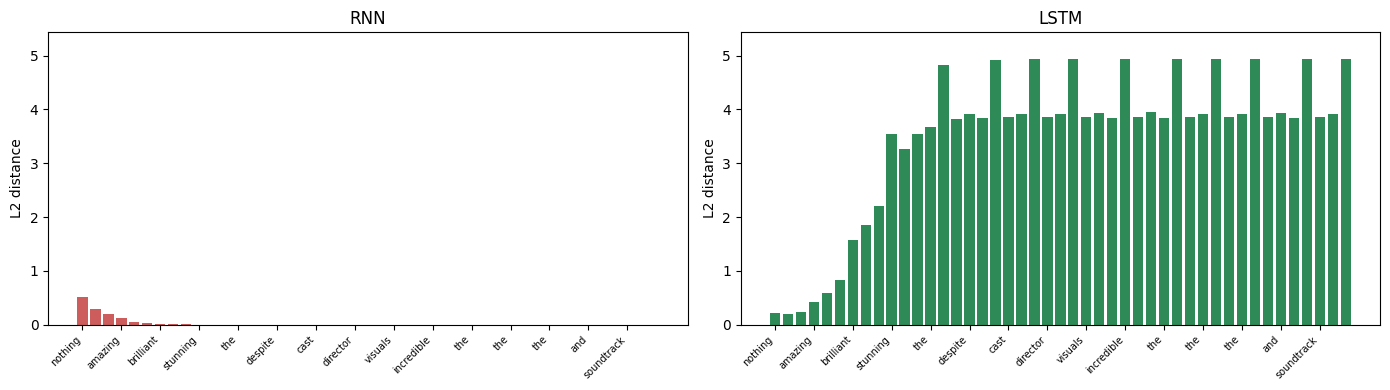

In [ ]:
with torch.no_grad():
    rnn_states_neg = torch.stack(run_rnn(rnn_long, embs_long_neg))
    rnn_states_pos = torch.stack(run_rnn(rnn_long, embs_long_pos))
    diffs_rnn = torch.norm(rnn_states_neg - rnn_states_pos, dim=1)

    lstm_states_neg = torch.stack(run_lstm(lstm_cell, embs_long_neg))
    lstm_states_pos = torch.stack(run_lstm(lstm_cell, embs_long_pos))
    diffs_lstm = torch.norm(lstm_states_neg - lstm_states_pos, dim=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ymax = max(diffs_rnn.max().item(), diffs_lstm.max().item()) * 1.1

axes[0].bar(range(len(tokens_long)), diffs_rnn.numpy(), color="indianred")
axes[0].set_title("RNN")
axes[0].set_ylabel("L2 distance")
axes[0].set_ylim(0, ymax)
axes[0].set_xticks(range(0, len(tokens_long), 3))
axes[0].set_xticklabels([tokens_long[i] for i in range(0, len(tokens_long), 3)], rotation=45, ha="right", fontsize=7)

axes[1].bar(range(len(tokens_long)), diffs_lstm.numpy(), color="seagreen")
axes[1].set_title("LSTM")
axes[1].set_ylabel("L2 distance")
axes[1].set_ylim(0, ymax)
axes[1].set_xticks(range(0, len(tokens_long), 3))
axes[1].set_xticklabels([tokens_long[i] for i in range(0, len(tokens_long), 3)], rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.show()

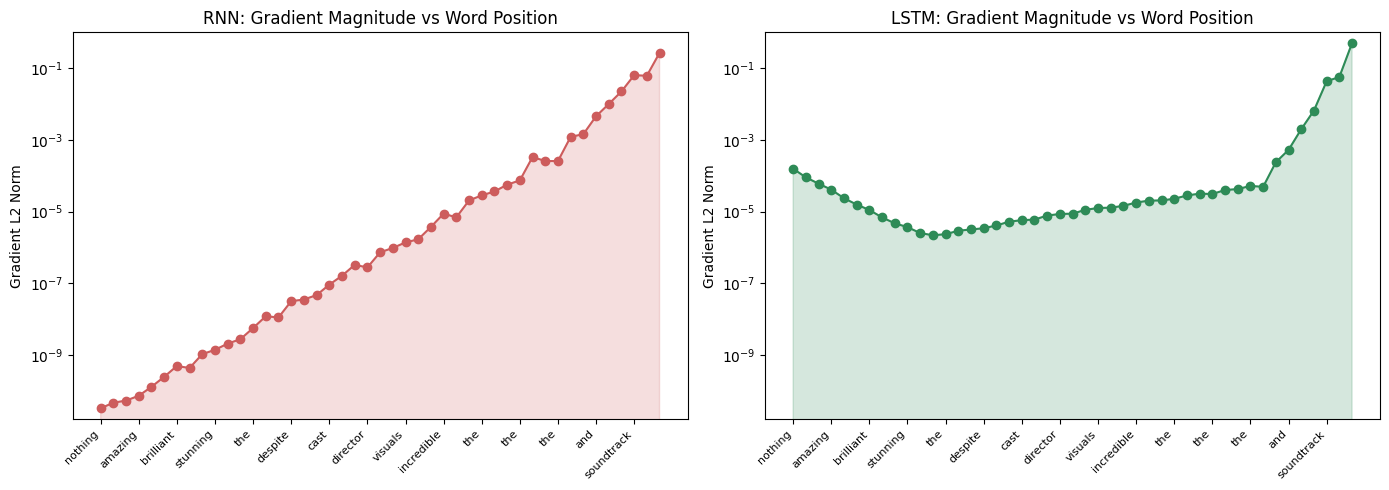

In [ ]:
# @title Visualize Gradient Flow

embs_for_rnn = embs_long_pos.clone().detach().requires_grad_(True)
embs_for_lstm = embs_long_pos.clone().detach().requires_grad_(True)

states_rnn = run_rnn(rnn_long, embs_for_rnn)
logit_rnn = cls_rnn_long(states_rnn[-1])

states_lstm = run_lstm(lstm_cell, embs_for_lstm)
logit_lstm = cls_lstm(states_lstm[-1])

logit_rnn.backward()
logit_lstm.backward()

# extract the L2 norm (magnitude) of the gradients at each timestep
rnn_grad_norms = embs_for_rnn.grad.norm(dim=1).numpy()
lstm_grad_norms = embs_for_lstm.grad.norm(dim=1).numpy()

y_min = min(rnn_grad_norms.min(), lstm_grad_norms.min()) * 0.5
y_max = max(rnn_grad_norms.max(), lstm_grad_norms.max()) * 2.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot RNN Gradients
axes[0].plot(range(len(tokens_long)), rnn_grad_norms, marker='o', color='indianred')
axes[0].fill_between(range(len(tokens_long)), rnn_grad_norms, color='indianred', alpha=0.2)
axes[0].set_title("RNN: Gradient Magnitude vs Word Position")
axes[0].set_ylabel("Gradient L2 Norm")
axes[0].set_xticks(range(0, len(tokens_long), 3))
axes[0].set_xticklabels([tokens_long[i] for i in range(0, len(tokens_long), 3)], rotation=45, ha="right", fontsize=8)
axes[0].set_yscale('log')
axes[0].set_ylim(y_min, y_max)

# plot LSTM Gradients
axes[1].plot(range(len(tokens_long)), lstm_grad_norms, marker='o', color='seagreen')
axes[1].fill_between(range(len(tokens_long)), lstm_grad_norms, color='seagreen', alpha=0.2)
axes[1].set_title("LSTM: Gradient Magnitude vs Word Position")
axes[1].set_ylabel("Gradient L2 Norm")
axes[1].set_xticks(range(0, len(tokens_long), 3))
axes[1].set_xticklabels([tokens_long[i] for i in range(0, len(tokens_long), 3)], rotation=45, ha="right", fontsize=8)
axes[1].set_yscale('log')
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()